## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile

url = 'https://drive.upm.es/s/2DDPE2zHw5dbM3G/download'
zip_name = 'dataset.zip'

r = requests.get(url, stream=True)
with open(zip_name, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024):
        f.write(chunk)

if os.path.getsize(zip_name) < 10000:
    print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
else:
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")

    target_file = 'xview_ann_train.json'
    found_path = None

    for root, dirs, files in os.walk("."):
        if target_file in files:
            found_path = os.path.join(root, target_file)
            break

    if found_path:
        print(f"SUCCÈS : Fichier trouvé à : {found_path}")

        import json
        json_file = found_path

        with open(json_file) as ifs:
            json_data = json.load(ifs)
        print("Base de données chargée avec succès !")

    else:
        print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_recognition/xview_ann_train.json
Base de données chargée avec succès !


In [2]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Policy:", mixed_precision.global_policy())

2026-03-07 10:51:00.053045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772880660.378476      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772880660.474436      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772880661.283194      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772880661.283240      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772880661.283243      24 computation_placer.cc:177] computation placer alr

Policy: <DTypePolicy "mixed_float16">


In [3]:
import tensorflow as tf

# Vérifie la présence de processeurs graphiques
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configuration pour ne pas allouer toute la mémoire d'un coup
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU activé : {len(gpus)} processeur(s) détecté(s)")
    except RuntimeError as e:
        print(e)
else:
    print("GPU non détecté. Activez l'accélérateur dans les réglages du notebook.")

GPU activé : 1 processeur(s) détecté(s)


In [4]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [5]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [6]:
!pip install rasterio

In [7]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('./xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [8]:
import json

# Load database
json_file = './xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [9]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)
labels = [img.objects[0].category for img in anns]

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [10]:
IMG_SIZE   = 224   
batch_size = 16   
n_models   = 3
BACKBONE_NAME = 'EfficientNetB2' 

In [11]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.15, random_state=42, shuffle=True, stratify=labels)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 15934
Number of validation images: 2812


In [12]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Rescaling,
    GlobalAveragePooling2D, SpatialDropout2D,
    RandomRotation, RandomZoom, RandomFlip
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.losses import CategoricalCrossentropy

BACKBONES = {
    'EfficientNetB0': tf.keras.applications.EfficientNetB0,
    'EfficientNetB2': tf.keras.applications.EfficientNetB2,
    'EfficientNetB3': tf.keras.applications.EfficientNetB3,
}

def create_transfer_model(backbone_name='EfficientNetB2',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3),
                           num_classes=13,
                           freeze_last_only=True,
                           label_smoothing=0.1,
                           lr=1e-3):
    img_input = Input(shape=input_shape, name='img_input')

    # Augmentation dans le modèle — actif seulement en training=True
    x = RandomFlip("horizontal_and_vertical")(img_input)
    x = RandomRotation(0.15)(x)       # ±~15° utile pour imagerie satellite
    x = RandomZoom(0.1)(x)            # zoom léger
    x = Rescaling(255.0)(x)           # [0,1] → [0,255] pour EfficientNet

    BackboneClass = BACKBONES[backbone_name]
    backbone = BackboneClass(
        include_top=False, weights='imagenet',
        input_shape=input_shape, pooling=None
    )

    if freeze_last_only:
        backbone.trainable = True
        backbone.layers[-1].trainable = False
    else:
        backbone.trainable = False

    x = backbone(x, training=False)
    x = SpatialDropout2D(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=img_input, outputs=outputs)
    loss  = CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(optimizer=Nadam(lr), loss=loss, metrics=['accuracy'])
    return model

In [13]:
#from tensorflow.keras.optimizers import Adam
#
## Learning rate is changed to 0.001
#opt = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
#model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
#reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=10, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, early_stop, terminate]

In [15]:
import numpy as np
import tensorflow as tf

def mixup(images, labels, alpha=0.2):
    n    = len(images)
    lam  = np.random.beta(alpha, alpha, size=n).astype(np.float32)
    lam  = np.maximum(lam, 1 - lam)
    perm = np.random.permutation(n)
    mixed_x = (lam[:, None, None, None] * images
                + (1 - lam[:, None, None, None]) * images[perm])
    mixed_y = lam[:, None] * labels + (1 - lam[:, None]) * labels[perm]
    return mixed_x.astype(np.float32), mixed_y.astype(np.float32)


def generator_images(objs, batch_size, do_shuffle=False,
                     do_mixup=False, class_weights=None):
    num_classes = len(categories)
    cat_list    = list(categories.values())

    images_buf = np.zeros((batch_size, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    labels_buf = np.zeros((batch_size, num_classes), dtype=np.float32)

    while True:
        if do_shuffle:
            np.random.shuffle(objs)

        for start in range(0, len(objs) - (len(objs) % batch_size), batch_size):
            group     = objs[start : start + batch_size]
            real_size = len(group)

            for j, (filename, obj) in enumerate(group):
                img = load_geoimage(filename)
                t   = tf.image.convert_image_dtype(
                          tf.convert_to_tensor(img), tf.float32)
                t   = tf.image.resize(t, [IMG_SIZE, IMG_SIZE], method='bilinear')

                # Augmentation CPU légère (complète celle dans le modèle)
                t = tf.image.random_flip_left_right(t)
                t = tf.image.random_flip_up_down(t)
                t = tf.image.random_brightness(t, max_delta=0.15)
                t = tf.image.random_contrast(t, 0.8, 1.2)
                t = tf.clip_by_value(t, 0.0, 1.0)

                images_buf[j] = t.numpy()
                idx = cat_list.index(obj.category)
                labels_buf[j] = tf.keras.utils.to_categorical(idx, num_classes)

            imgs = images_buf[:real_size]
            lbls = labels_buf[:real_size]

            if do_mixup and real_size > 1:
                imgs, lbls = mixup(imgs, lbls, alpha=0.2)

            yield imgs.copy(), lbls.copy()

In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

print('Calcul des poids de classes...')
y_train_indices = [list(categories.values()).index(obj.category) for _, obj in objs_train]
weights = compute_class_weight('balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weights = dict(enumerate(weights))

# Ajustements manuels (exemple)
class_weights[3] *= 1.5   # Truck
class_weights[9] *= 1.5   # Helipad

batch_size = 128

train_generator = generator_images(objs_train, batch_size, do_shuffle=True, class_weights=class_weights)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)


Calcul des poids de classes...


In [17]:
import gc
import tensorflow as tf

train_size = len(objs_train)

train_generator = generator_images(objs_train, batch_size,
                                   do_shuffle=True, do_mixup=True)
valid_generator = generator_images(objs_valid, batch_size,
                                   do_shuffle=False, do_mixup=False)

models = []
for i in range(n_models):
    print(f"Création du modèle {i+1}/{n_models}  [{BACKBONE_NAME}]")
    model = create_transfer_model(
        backbone_name=BACKBONE_NAME,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=len(categories),
        freeze_last_only=True,
        label_smoothing=0.1,
        lr=1e-3
    )
    models.append(model)

Création du modèle 1/3  [EfficientNetB2]


I0000 00:00:1772880703.403343      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Création du modèle 2/3  [EfficientNetB2]
Création du modèle 3/3  [EfficientNetB2]


In [18]:
import math
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy

epochs_p1   = 20   # phase 1 : backbone quasi-gelé
epochs_p2   = 15   # phase 2 : fine-tuning profond
train_steps = math.ceil(len(objs_train) / batch_size)
valid_steps = math.ceil(len(objs_valid) / batch_size)

print('Entraînement des modèles')
for i, model in enumerate(models):
    print(f"\n=== Modèle {i+1}/{n_models} ===")

    # ── Phase 1 : tête + derniers blocs ──────────────────────────────
    print("Phase 1 : backbone quasi-gelé")
    ckpt = ModelCheckpoint(
        f'model_{i}.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
    early = EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    )

    model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        validation_data=valid_generator,
        validation_steps=valid_steps,
        epochs=epochs_p1,
        callbacks=[ckpt, early, reduce_lr]
    )

    # ── Phase 2 : fine-tuning des 30 dernières couches du backbone ───
    print("\nPhase 2 : fine-tuning des 30 dernières couches")
    for layer in model.layers:
        if hasattr(layer, 'layers'):          # identifie le backbone
            for bl in layer.layers[-30:]:
                bl.trainable = True

    model.compile(
        optimizer=Nadam(1e-5),               # LR très faible
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    ckpt2  = ModelCheckpoint(
        f'model_{i}.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
    early2 = EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    )

    model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        validation_data=valid_generator,
        validation_steps=valid_steps,
        epochs=epochs_p2,
        callbacks=[ckpt2, early2]
    )

Entraînement des modèles

=== Modèle 1/3 ===
Phase 1 : backbone quasi-gelé
Epoch 1/20


E0000 00:00:1772880775.964171      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772880787.563066      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5122 - loss: 1.8013
Epoch 1: val_accuracy improved from -inf to 0.66371, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.5129 - loss: 1.7998 - val_accuracy: 0.6637 - val_loss: 1.3463 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6819 - loss: 1.4228
Epoch 2: val_accuracy improved from 0.66371 to 0.73366, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.6820 - loss: 1.4228 - val_accuracy: 0.7337 - val_loss: 1.1622 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7122 - loss: 1.3569
Epoch 3: val_accuracy improved from 0.73366 to 0.76030, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.7122 - loss: 1.3568 - val_accuracy: 0.7603 - val_loss: 1.0879 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7319 - los

E0000 00:00:1772886396.990808      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8526 - loss: 1.0571
Epoch 1: val_accuracy improved from -inf to 0.82031, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.8526 - loss: 1.0571 - val_accuracy: 0.8203 - val_loss: 0.9873
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8556 - loss: 1.0541
Epoch 2: val_accuracy improved from 0.82031 to 0.82280, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8556 - loss: 1.0541 - val_accuracy: 0.8228 - val_loss: 0.9839
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8505 - loss: 1.0615
Epoch 3: val_accuracy improved from 0.82280 to 0.82919, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8506 - loss: 1.0614 - val_accuracy: 0.8292 - val_loss: 0.9758
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8531 - loss: 1.0536
Epoch 4: val_accuracy did not improve from 0.82919
125/125 ━━━

...

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8503 - loss: 1.0644
Epoch 1: val_accuracy improved from -inf to 0.81783, saving model to model_1.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 358s 2s/step - accuracy: 0.8503 - loss: 1.0645 - val_accuracy: 0.8178 - val_loss: 0.9888
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8403 - loss: 1.0723
Epoch 2: val_accuracy did not improve from 0.81783
125/125 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.8404 - loss: 1.0722 - val_accuracy: 0.8100 - val_loss: 0.9959
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8530 - loss: 1.0572
Epoch 3: val_accuracy did not improve from 0.81783
125/125 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.8530 - loss: 1.0572 - val_accuracy: 0.8114 - val_loss: 1.0013
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8509 - loss: 1.0510
Epoch 4: val_accuracy did not improve from 0.81783
125/125 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.8510 - loss: 1.0510 - val

E0000 00:00:1772897339.024947      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4994 - loss: 1.8213
Epoch 1: val_accuracy improved from -inf to 0.68537, saving model to model_2.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.5001 - loss: 1.8197 - val_accuracy: 0.6854 - val_loss: 1.2819 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6779 - loss: 1.4344
Epoch 2: val_accuracy improved from 0.68537 to 0.75568, saving model to model_2.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.6779 - loss: 1.4342 - val_accuracy: 0.7557 - val_loss: 1.1340 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7061 - loss: 1.3709
Epoch 3: val_accuracy improved from 0.75568 to 0.76811, saving model to model_2.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.7062 - loss: 1.3708 - val_accuracy: 0.7681 - val_loss: 1.0911 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7264 - los

E0000 00:00:1772902907.435369      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8621 - loss: 1.0363
Epoch 1: val_accuracy improved from -inf to 0.80824, saving model to model_2.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.8621 - loss: 1.0362 - val_accuracy: 0.8082 - val_loss: 1.0198
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8707 - loss: 1.0163
Epoch 2: val_accuracy improved from 0.80824 to 0.82528, saving model to model_2.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8707 - loss: 1.0163 - val_accuracy: 0.8253 - val_loss: 0.9961
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8704 - loss: 1.0135
Epoch 3: val_accuracy did not improve from 0.82528
125/125 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.8704 - loss: 1.0136 - val_accuracy: 0.8153 - val_loss: 1.0090
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8739 - loss: 1.0168
Epoch 4: val_accuracy did not improve from 0.82528
125/125 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - ac

#### Validation
Compute validation metrics.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [20]:
import numpy as np
import tensorflow as tf

y_true, y_pred = [], []
all_images = []
temp_true_labels = []

print("Chargement des données de validation...")
for ann in anns_valid:
    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE], method='bilinear')

    for obj_pred in ann.objects:
        all_images.append(image_resized.numpy())
        temp_true_labels.append(obj_pred.category)

if all_images:
    X_valid = np.array(all_images)
    print(f"Lancement de la prédiction sur {len(X_valid)} objets...")

    # Moyenne des prédictions des 3 modèles
    all_predictions = np.mean([
        model.predict(X_valid, batch_size=128, verbose=1) for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i in range(len(all_predictions)):
        pred_category = category_names[np.argmax(all_predictions[i])]
        y_true.append(temp_true_labels[i])
        y_pred.append(pred_category)

Chargement des données de validation...
Lancement de la prédiction sur 2812 objets...
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 958ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step


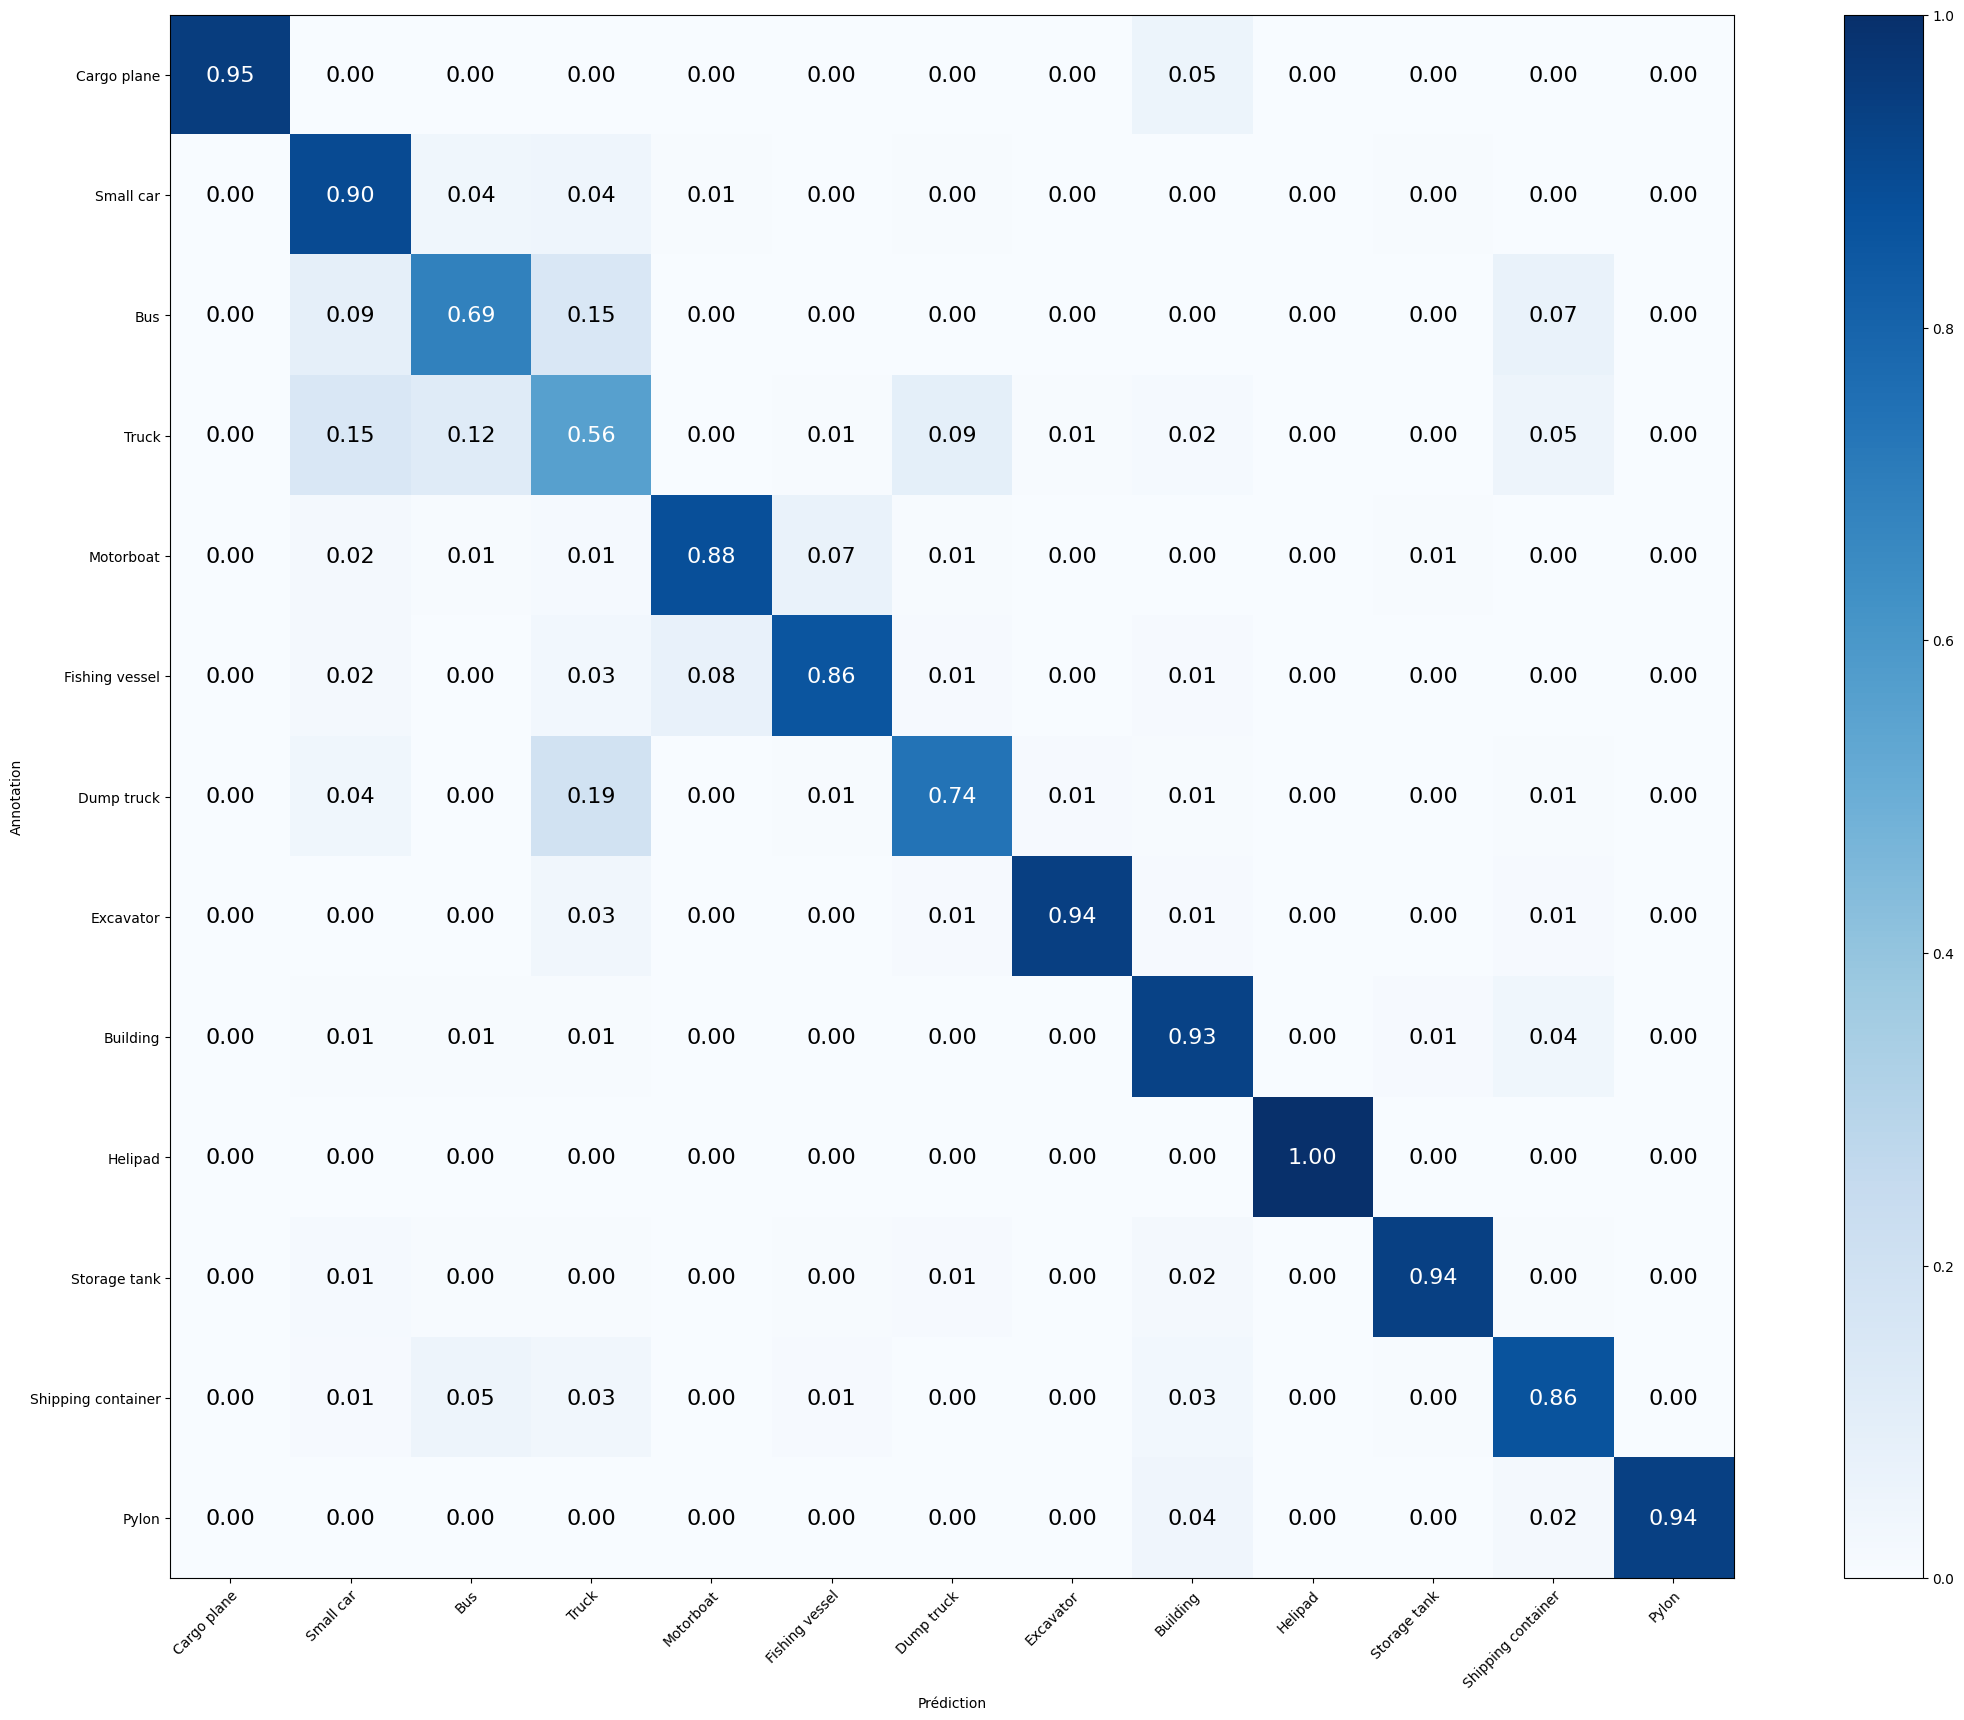

In [21]:
from sklearn.metrics import confusion_matrix

def draw_confusion_matrix(cm, categories):
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=list(categories.values()), yticklabels=list(categories.values()),
           ylabel='Annotation', xlabel='Prédiction')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm_norm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm_norm[i, j], '.2f'),
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

# Calcul et affichage
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [22]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 83.570%
Mean Recall: 85.969%
Mean Precision: 86.641%
> Cargo plane: Recall: 94.737% Precision: 98.901% Specificity: 99.963% Dice: 96.774%
> Small car: Recall: 89.579% Precision: 82.625% Specificity: 95.936% Dice: 85.962%
> Bus: Recall: 68.679% Precision: 71.094% Specificity: 97.095% Dice: 69.866%
> Truck: Recall: 56.024% Precision: 60.984% Specificity: 95.202% Dice: 58.399%
> Motorboat: Recall: 88.125% Precision: 92.157% Specificity: 99.548% Dice: 90.096%
> Fishing vessel: Recall: 85.849% Precision: 82.727% Specificity: 99.298% Dice: 84.259%
> Dump truck: Recall: 74.054% Precision: 77.401% Specificity: 98.477% Dice: 75.691%
> Excavator: Recall: 94.068% Precision: 95.690% Specificity: 99.814% Dice: 94.872%
> Building: Recall: 92.764% Precision: 94.697% Specificity: 98.768% Dice: 93.721%
> Helipad: Recall: 100.000% Precision: 100.000% Specificity: 100.000% Dice: 100.000%
> Storage tank: Recall: 93.636% Precision: 94.931% Specificity: 99.576% Dice: 94.279%
> Shipping contai

#### Testing
Try to improve the results provided in the competition.

In [23]:
import os
import numpy as np

anns = []
root_dir = './xview_recognition/'
test_dir = os.path.join(root_dir, 'xview_test')
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        rel_dir = os.path.relpath(dirpath, root_dir)
        clean_filename = os.path.join(rel_dir, filename)
        image = GenericImage(clean_filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = os.path.basename(dirpath)
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [24]:
import numpy as np
import tensorflow as tf

predictions_data = {"images": {}, "annotations": {}}
all_test_images = []
metadata = [] 
ann_id = 0

print("Préparation des images de test...")
for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img_final = image_resized.numpy()

    for obj_pred in ann.objects:
        all_test_images.append(img_final)
        metadata.append({
            "image_id": ann.filename.split('/')[-1],
            "bbox": [int(x) for x in obj_pred.bb]
        })

if all_test_images:
    X_test = np.array(all_test_images)
    print(f"Prédiction en cours sur {len(X_test)} détections...")
    # Moyenne des prédictions des 3 modèles
    all_preds = np.mean([
        model.predict(X_test, batch_size=128, verbose=1) for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i, pred in enumerate(all_preds):
        pred_category = category_names[np.argmax(pred)]
        predictions_data["annotations"][ann_id] = {
            "image_id": metadata[i]["image_id"],
            "category_id": pred_category,
            "bbox": metadata[i]["bbox"]
        }
        ann_id += 1

print("Test terminé.")

Préparation des images de test...
Prédiction en cours sur 2365 détections...
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 874ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step
Test terminé.


In [25]:
#for i, model in enumerate(models):
#    model.load_weights(f'model_{i}.keras')

In [26]:
import json
with open('prediction.json', 'w') as f:
    json.dump(predictions_data, f)